In [18]:


import os
from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()


True

In [19]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = "..."

model = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [ ]:
response = model.invoke("Why do parrots talk?")
print(response)

In [25]:
from langchain.chat_models import init_chat_model

# Initialize the Ollama model
model = init_chat_model(
    model="nemotron-3-super:cloud",          # Replace with any model you have downloaded in Ollama
    model_provider="ollama"       # Directs LangChain to use the Ollama integration
)

# Test the model
response = model.invoke("Hello,what is the capital of France?")
print(response.content)


The capital of France is **Paris**.  

It has been the capital since the 10th century and is located in the north-central part of the country, along the Seine River. Paris is also France's largest city and a global hub for art, fashion, gastronomy, and culture.  

Let me know if you'd like any additional details! 😊


In [32]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

class State(BaseModel):
    name: str
    value: str
# #from langchain_core.messages import MessageState
# from langgraph.graph import StateGraph, START, END

# class State(MessageState):
#     name: str
#     value: str

In [34]:
from langchain_core.messages import SystemMessage

system_message = SystemMessage(content="You are a helpful assistant and you poliytely answer the user's questions.")

def node_llm(state:State) -> State:
    # Here you would call your LLM and return the response
    return {"message": [model.invoke(system_message,state["message"])]}

In [35]:
from langgraph.graph import StateGraph, START, END
#Define edge class

builder = StateGraph(State)

builder.add_node('node_llm', node_llm)


builder.add_edge(START, 'node_llm')
builder.add_edge('node_llm', END)

graph = builder.compile()


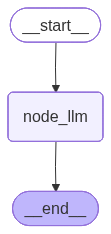

In [36]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))